This notebooks investigates the (validation) results of the GNN models developed using the custom CV approach.   
The results from all validation folds are combined and analyzed.

**It is important to note that these are results are from multiple GNN models!!**   
**All plots/visualisations are based on validation data!!**

In [1]:
from pathlib import Path
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import spatial_hazard as sh
import sim_ranking as sr
import ml_tools as mlt

In [2]:
results_dir = "/Users/claudy/dev/work/data/sim_ranking/results/gnn/0927_2008_nzgmdb3p4_3_5_long_run"

In [5]:
results_dir = Path(results_dir)
warnings.simplefilter(action='ignore', category=FutureWarning)

**Result Directory:** `{python} str(results_dir)`


In [6]:
# Load the data
metrics = pd.read_pickle(results_dir / "metrics.pickle")
train_metrics = pd.DataFrame({cur_key: cur_item["loss_hist_train"] for cur_key, cur_item in metrics.items()})
val_metrics = pd.DataFrame({cur_key: cur_item["loss_hist_val"] for cur_key, cur_item in metrics.items()})

val_results = pd.read_parquet(results_dir / "val_results.parquet")

In [7]:
# Compute residuals
val_res_df = sr.ml.gnn_gm.get_residuals(val_results)

val_res_mean_std_df = pd.concat((val_res_df[sr.constants.PSA_KEYS].mean(axis=0), val_res_df[sr.constants.PSA_KEYS].std(axis=0)), axis=1)
val_res_mean_std_df.columns = ["mean", "std"]

In [8]:
# Plot config
plot_ims = ["pSA_0.01", "pSA_0.1", "pSA_0.5", "pSA_1.0", "pSA_3.0", "pSA_10.0"]

### Loss Comparison Between CV-Iterations

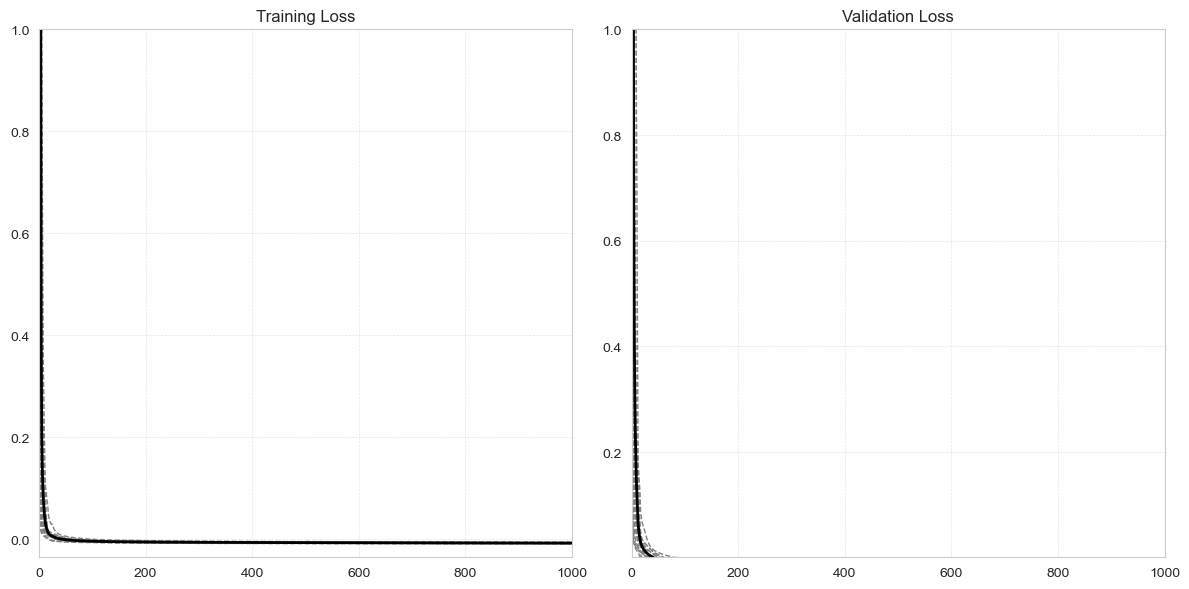

In [16]:
y_min = min(train_metrics.min().min(), val_metrics.min().min())
# y_max = max(train_metrics.abs().max().max(), val_metrics.abs().max().max())
# y_max = y_min * 100
y_max = 1

fig, (ax1, ax2)  = plt.subplots(1, 2, figsize=(12, 6))

cur_mean = train_metrics.mean(axis=1)
cur_std = train_metrics.std(axis=1)
ax1.plot(train_metrics.index.values, train_metrics.values, c="gray", linewidth=1.0, linestyle="--")
ax1.plot(train_metrics.index.values, cur_mean, c="black", linewidth=2.0)
# ax1.set_yscale('log')
ax1.set_ylim(y_min, y_max)
ax1.set_title("Training Loss")
ax1.set_xlim(0, train_metrics.shape[0])
ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")


cur_mean = val_metrics.mean(axis=1)
cur_std = val_metrics.std(axis=1)
ax2.plot(val_metrics.index.values, val_metrics.values, c="gray", linewidth=1.0, linestyle="--")
ax2.plot(val_metrics.index.values, cur_mean, c="black", linewidth=2.0)
# ax2.set_yscale('log')
ax2.set_ylim(0.001, 1)
ax2.set_title("Validation Loss")
ax2.set_xlim(0, val_metrics.shape[0])
ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")


fig.tight_layout()

### Comparison Of Median Loss

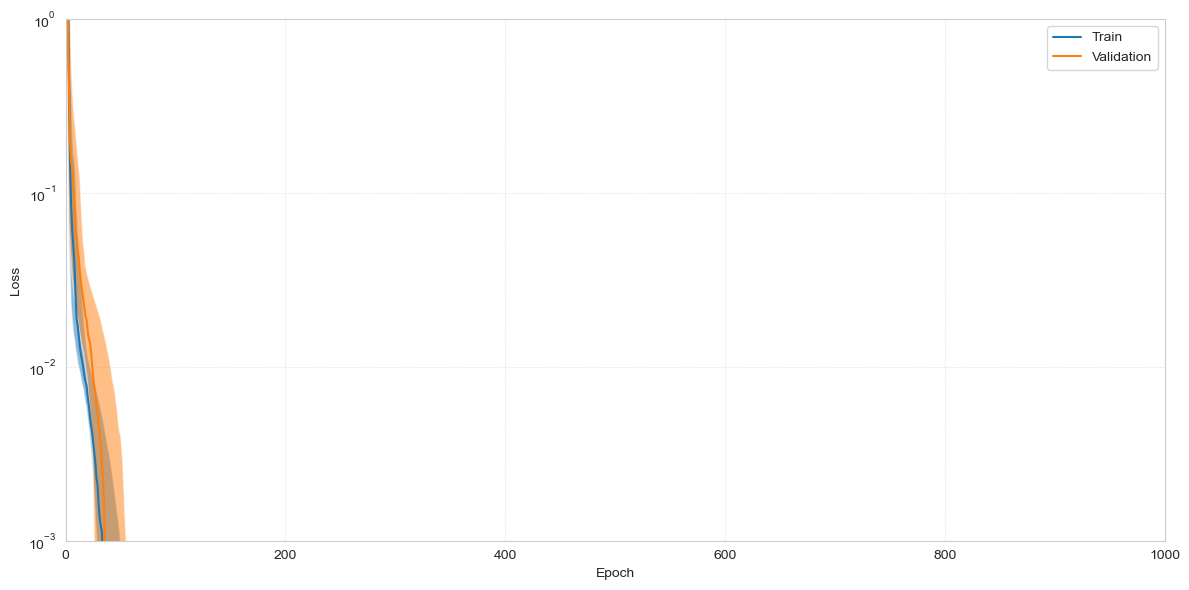

In [13]:
train_median = train_metrics.median(axis=1)
train_16, train_84 = np.percentile(train_metrics, [16, 84], axis=1)


val_median = val_metrics.median(axis=1)
val_16, val_84 = np.percentile(val_metrics, [16, 84], axis=1)

fig, ax1  = plt.subplots(1, 1, figsize=(12, 6))

ax1.plot(train_metrics.index.values, train_median, label="Train")
ax1.fill_between(train_metrics.index.values, train_16, train_84, alpha=0.5)

ax1.plot(val_metrics.index.values, val_median, label="Validation")
ax1.fill_between(val_metrics.index.values, val_16, val_84, alpha=0.5)

ax1.set_yscale('log')
ax1.set_ylim(0.001, 1)
ax1.set_xlim(0, train_metrics.shape[0])
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax1.legend()

fig.tight_layout()


### Residual Histograms

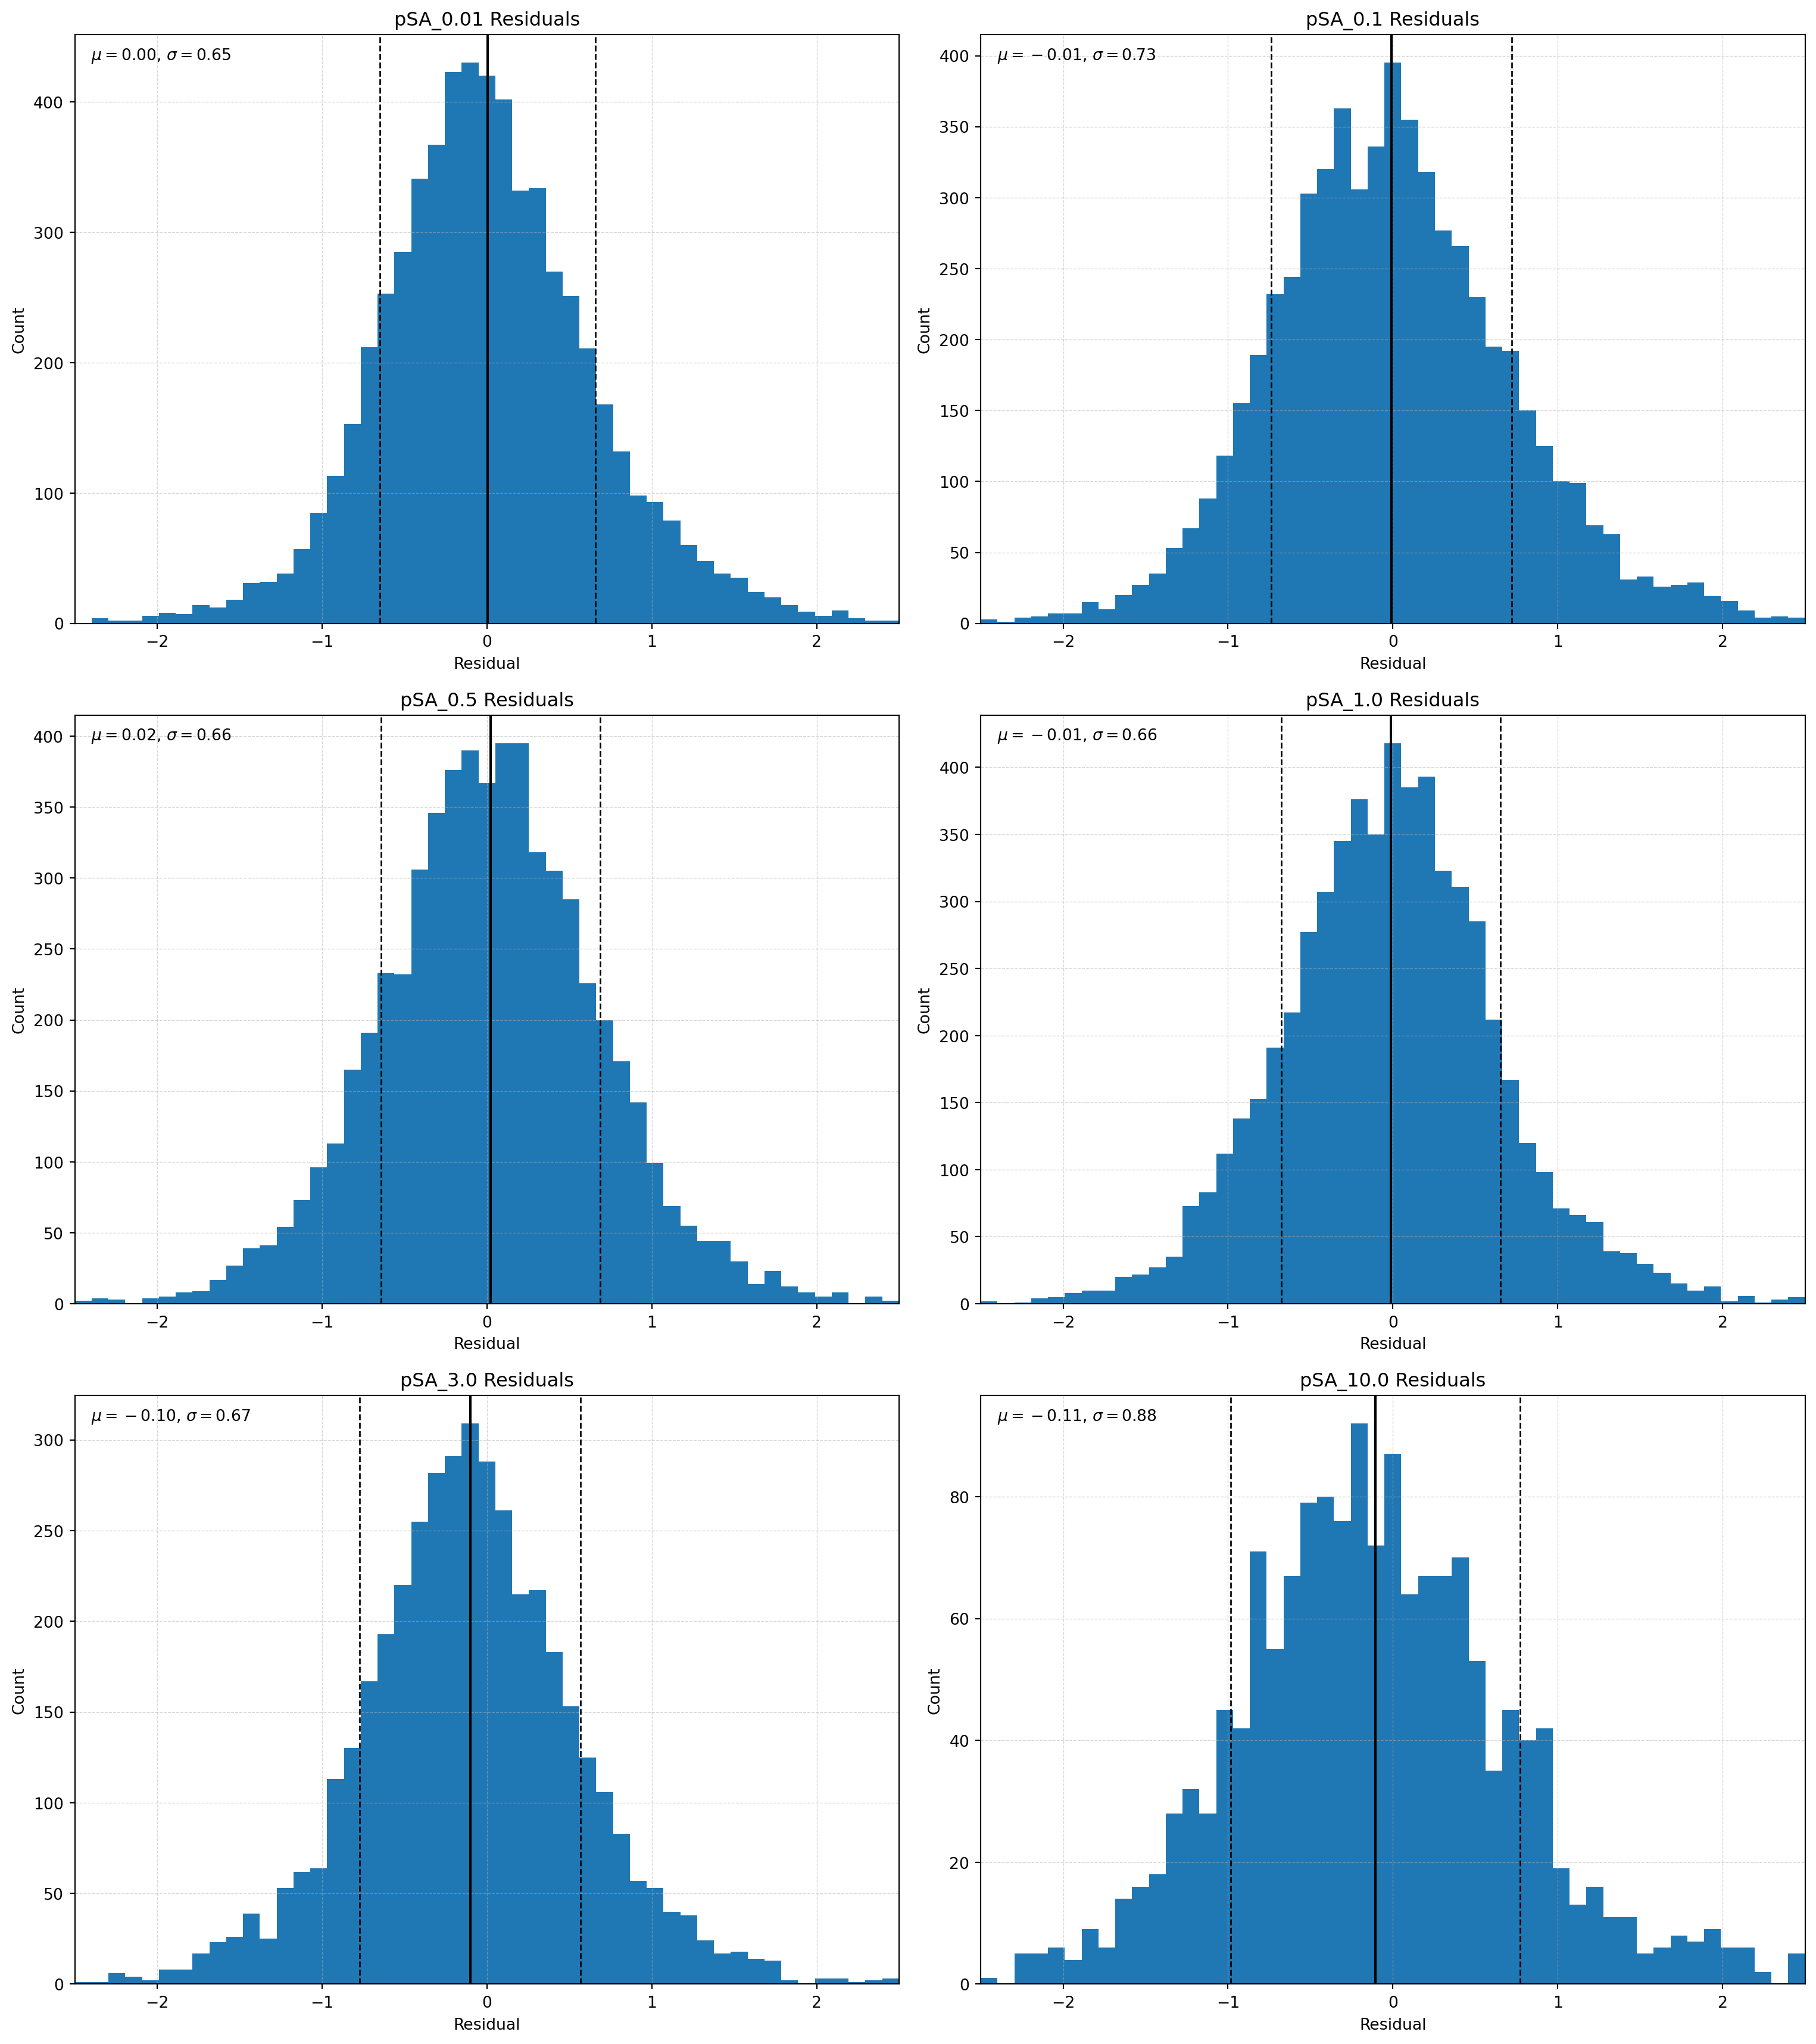

In [10]:
# cur_im = "pSA_0.1"
n_bins = 50
x_min, x_max = -2.5, 2.5
bins = np.linspace(x_min, x_max, n_bins)

fig, axs = mlt.plotting.get_fig_axes(len(plot_ims), 2, -1, (8, 6))

for cur_im, cur_ax in zip(plot_ims, axs):
    cur_train_mean = val_res_mean_std_df.loc[cur_im, "mean"]
    cur_train_std = val_res_mean_std_df.loc[cur_im, "std"]
    cur_ax.axvline(cur_train_mean, color="k", linestyle="-", label="Mean", linewidth=1.5)
    cur_ax.axvline(cur_train_mean + cur_train_std, color="k", linestyle="--", label="Std", linewidth=1.0)
    cur_ax.axvline(cur_train_mean - cur_train_std, color="k", linestyle="--", linewidth=1.0)
    cur_ax.hist(val_res_df[cur_im], bins=bins, label="Train Data")
    cur_ax.set_xlabel(f"Residual")
    cur_ax.set_ylabel(f"Count")
    cur_ax.grid(linewidth=0.5, alpha=0.5, linestyle="--")
    cur_ax.set_xlim(x_min, x_max )
    cur_ax.set_title(f"{cur_im} Residuals")

    cur_ax.text(0.02, 0.98, f"$\mu = {cur_train_mean:.2f}$, $\sigma = {cur_train_std:.2}$", horizontalalignment="left",
             verticalalignment="top", transform=cur_ax.transAxes)
    
fig.tight_layout()

### Bias & (Residual) Standard Deviation

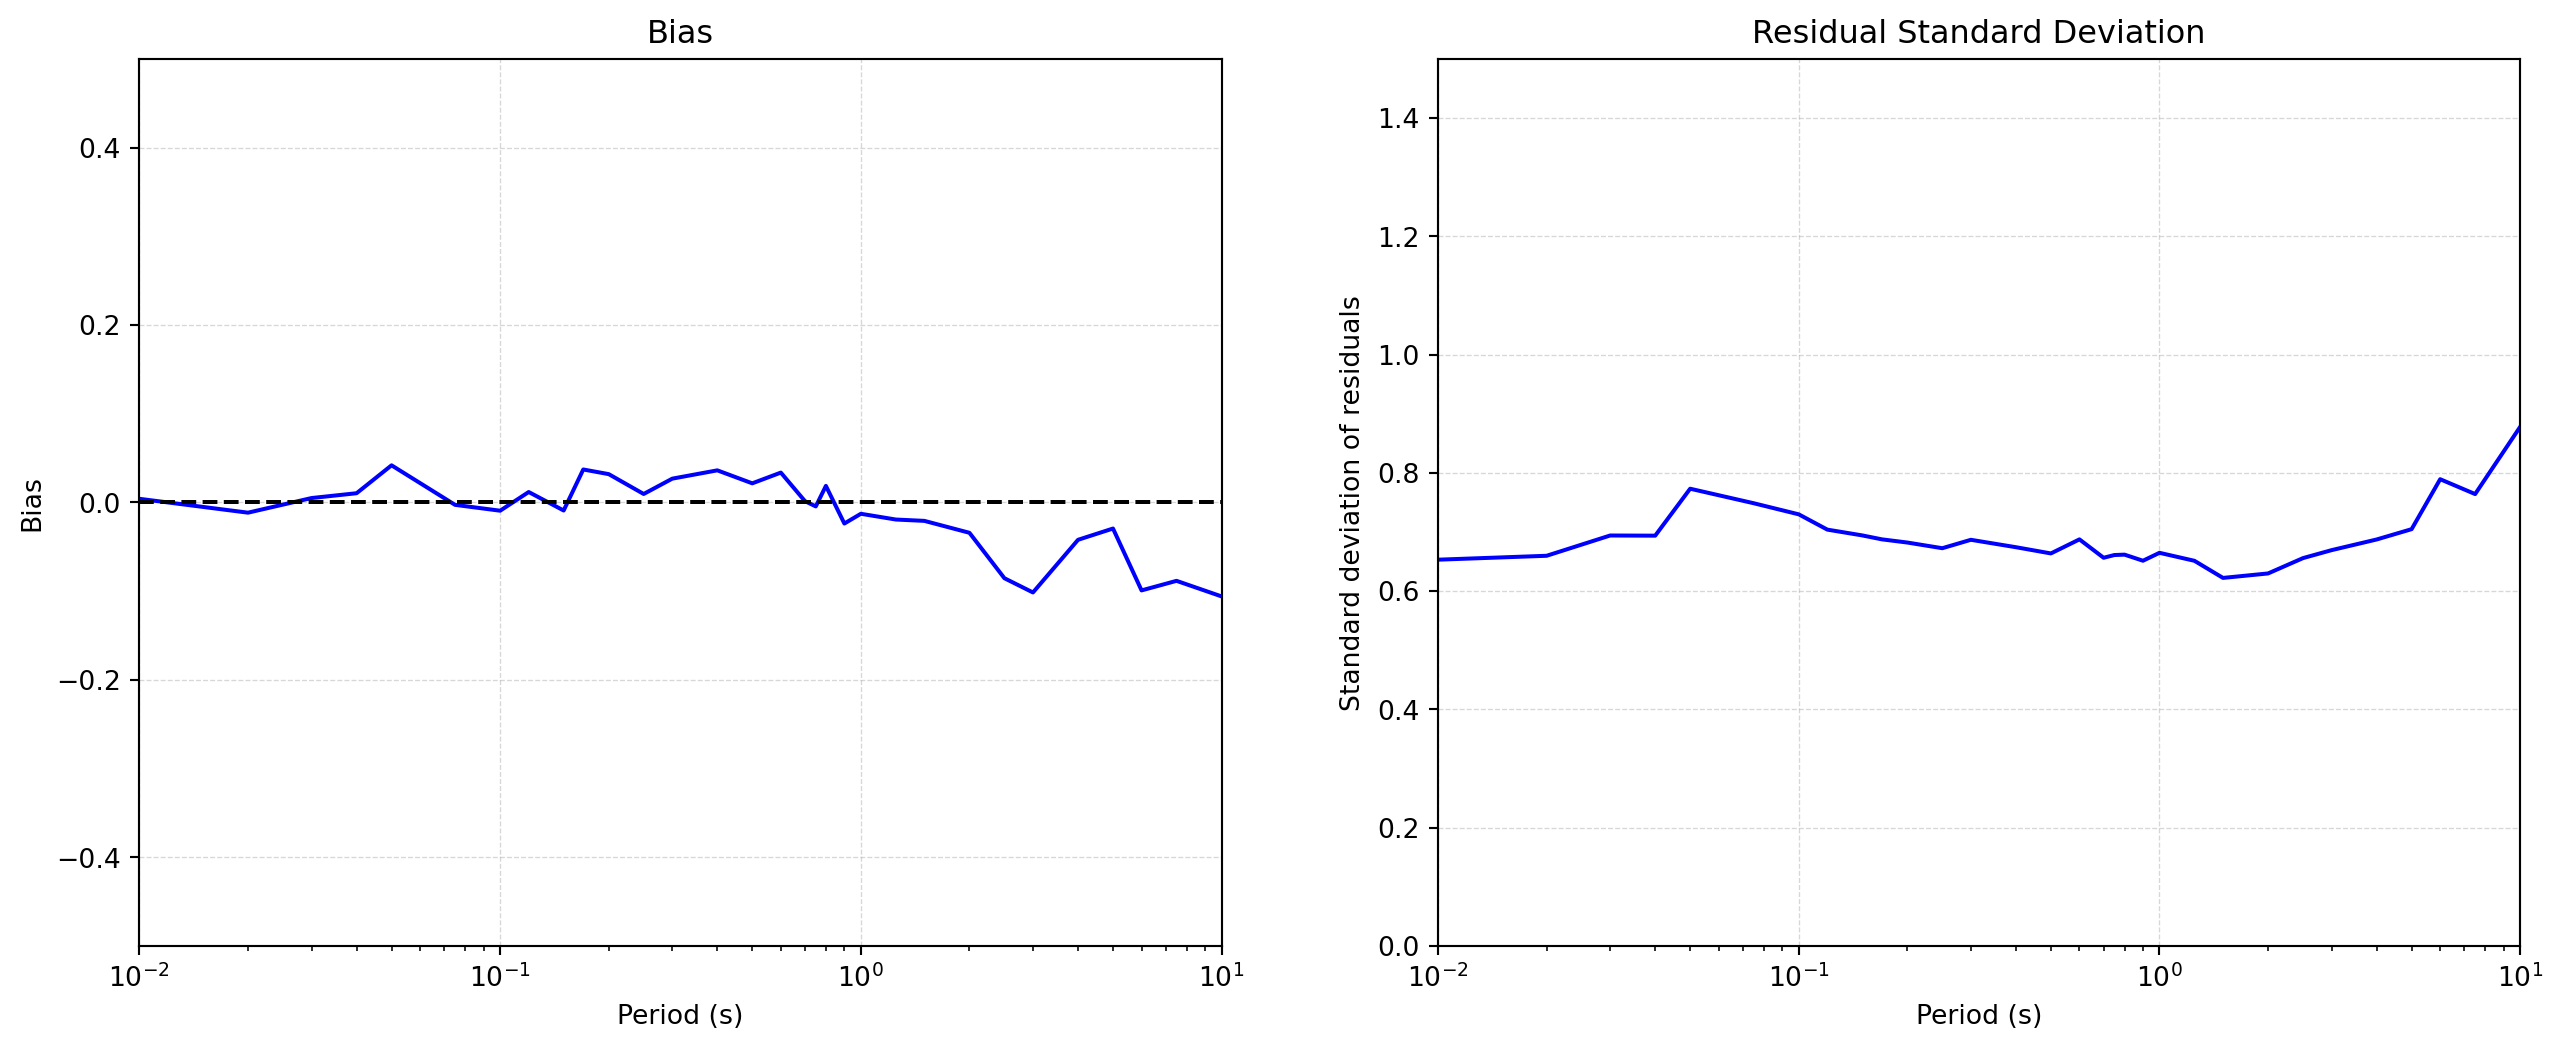

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.semilogx(sr.constants.PERIODS, val_res_mean_std_df.loc[sr.constants.PSA_KEYS, "mean"], c="b")
ax1.axhline(0, color="k", linestyle="--")
ax1.set_xlabel(f"Period (s)")
ax1.set_ylabel(f"Bias")
ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax1.set_xlim(0.01, 10)
ax1.set_ylim(-0.5, 0.5)
ax1.set_title("Bias")

ax2.semilogx(sr.constants.PERIODS, val_res_mean_std_df.loc[sr.constants.PSA_KEYS, "std"], c="b")
ax2.set_xlabel(f"Period (s)")
ax2.set_ylabel(f"Standard deviation of residuals")
ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax2.set_xlim(0.01, 10)
ax2.set_ylim(0, 1.5)
ax2.set_title("Residual Standard Deviation");

### Predicted Standard Deviation Histograms

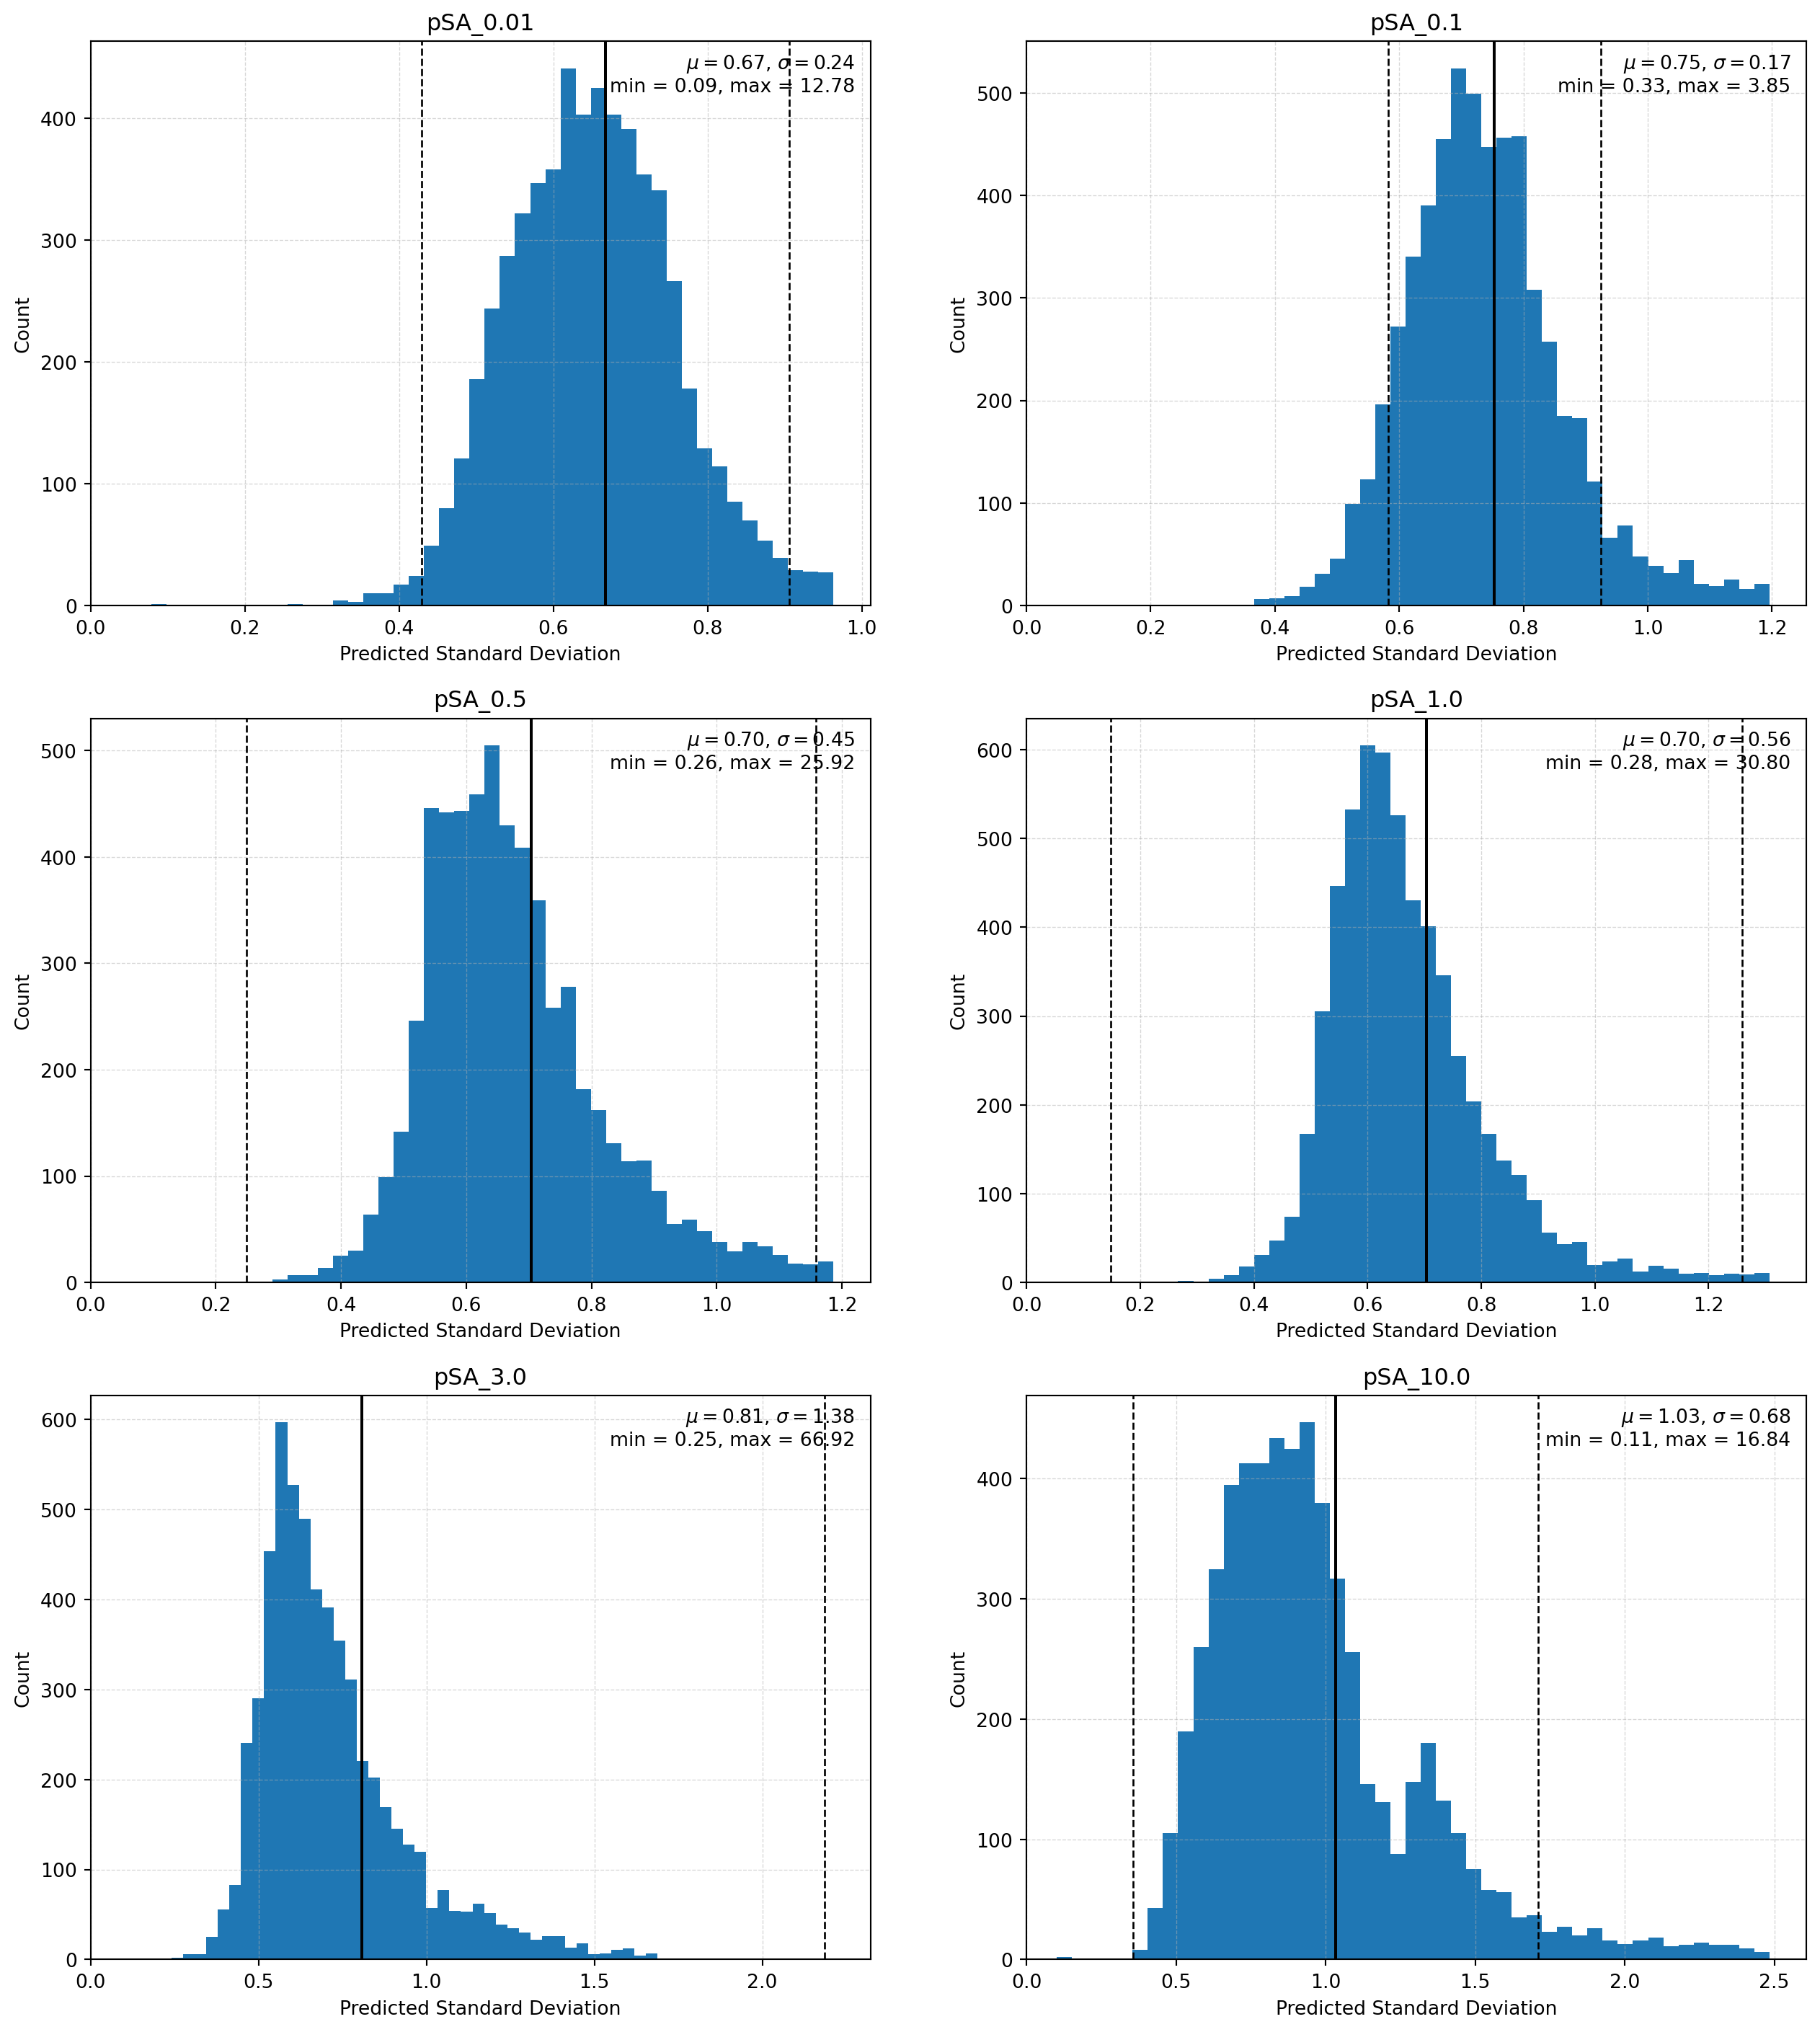

In [12]:
fig, axs = mlt.plotting.get_fig_axes(len(plot_ims), 2, -1, (8, 6))

n_bins = 50
for cur_im, cur_ax in zip(plot_ims, axs):
	cur_train_values = val_results[f"{cur_im}_pred_std"]
	cur_val_values = val_results[f"{cur_im}_pred_std"]

	bins = np.linspace(0, max(np.quantile(cur_train_values, 0.98), np.quantile(cur_val_values, 0.98)), n_bins)

	cur_train_mean = cur_train_values.mean()
	cur_train_std = cur_train_values.std()
	cur_ax.axvline(cur_train_mean, color="k", linestyle="-", label="Mean", linewidth=1.5)
	cur_ax.axvline(cur_train_mean + cur_train_std, color="k", linestyle="--", label="Std", linewidth=1.0)
	cur_ax.axvline(cur_train_mean - cur_train_std, color="k", linestyle="--", linewidth=1.0)
	cur_ax.hist(cur_train_values, bins=bins, label="Train Data")
	cur_ax.set_xlabel(f"Predicted Standard Deviation")
	cur_ax.set_ylabel(f"Count")
	cur_ax.set_xlim(0, None)
	cur_ax.grid(linewidth=0.5, alpha=0.5, linestyle="--")
	cur_ax.set_title(f"{cur_im}")

	cur_ax.text(0.98, 0.98, f"$\mu = {cur_train_mean:.2f}$, $\sigma = {cur_train_std:.2f}$\n"
                         f"min = {cur_train_values.min():.2f}, max = {cur_train_values.max():.2f}", horizontalalignment="right", verticalalignment="top", transform=cur_ax.transAxes)